有点复杂，懒得写备注了

### pop

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr 

# =========================
# 1. 路径设置
# =========================
geo_csv_path = r"C:\Users\dell\OneDrive\file\csv\geo_clf_grid.csv"
data_dir = r"F:\User_file\wyy\SPDB\part4_assess\pop\nc_add"
output_path = os.path.join(data_dir, "global_stats.csv")

# =========================
# 2. 读取网格分类表
# =========================
geo_df = pd.read_csv(
    geo_csv_path,
    usecols=["lon", "lat", "continent", "development"]
)

# 转为 xarray
geo_xr = geo_df.set_index(["lat", "lon"]).to_xarray()
continent_grid = geo_xr["continent"]
development_grid = geo_xr["development"]

# 原始 mask（后续每个文件只 reindex 一次）
mask_africa_raw = continent_grid == "Africa"
mask_asia_raw = continent_grid == "Asia"
mask_europe_raw = continent_grid == "Europe"
mask_n_america_raw = continent_grid == "North America"
mask_l_america_raw = continent_grid == "Latin America"

mask_developed_raw = development_grid == "Developed regions"
mask_developing_raw = development_grid == "Developing regions"

# =========================
# 3. 获取待处理nc文件
# =========================
nc_files = sorted(glob.glob(os.path.join(data_dir, "total_all*.nc")))

all_results = []

# =========================
# 4. 逐个文件处理
# =========================
for nc_file in nc_files:
    fname = os.path.basename(nc_file)
    print(f"Processing: {fname}")

    ds = xr.open_dataset(nc_file)

    # 提取 scene：文件名第三段
    fname_no_ext = os.path.splitext(fname)[0]
    parts = fname_no_ext.split("_")
    scene = parts[2] if len(parts) >= 3 else None

    if "year" not in ds.coords and "year" not in ds.dims:
        ds.close()
        raise ValueError(f"{fname} 中未找到 year 维度/坐标。")
    if "lat" not in ds.coords or "lon" not in ds.coords:
        ds.close()
        raise ValueError(f"{fname} 中未找到 lat/lon 坐标，请检查维度名称。")

    years = ds["year"].values

    # 收集所有存在的 pop_* 变量
    pop_vars = [f"pop_{i}" for i in range(100) if f"pop_{i}" in ds.data_vars]
    if not pop_vars:
        print(f"Warning: no pop_* variables found in {fname}, skipped.")
        ds.close()
        continue

    # 一次性拼接为 (seed, year, lat, lon)
    da_all = xr.concat([ds[v] for v in pop_vars], dim="seed")
    da_all = da_all.assign_coords(seed=[int(v.split("_")[1]) for v in pop_vars])

    # 只对齐一次 mask 到当前文件网格
    mask_africa = mask_africa_raw.reindex(lat=ds["lat"], lon=ds["lon"])
    mask_asia = mask_asia_raw.reindex(lat=ds["lat"], lon=ds["lon"])
    mask_europe = mask_europe_raw.reindex(lat=ds["lat"], lon=ds["lon"])
    mask_n_america = mask_n_america_raw.reindex(lat=ds["lat"], lon=ds["lon"])
    mask_l_america = mask_l_america_raw.reindex(lat=ds["lat"], lon=ds["lon"])

    mask_developed = mask_developed_raw.reindex(lat=ds["lat"], lon=ds["lon"])
    mask_developing = mask_developing_raw.reindex(lat=ds["lat"], lon=ds["lon"])

    # 一次性汇总，避免对每个 seed 重复循环计算
    pop_g = da_all.sum(dim=["lat", "lon"], skipna=True)

    pop_africa = da_all.where(mask_africa).sum(dim=["lat", "lon"], skipna=True)
    pop_asia = da_all.where(mask_asia).sum(dim=["lat", "lon"], skipna=True)
    pop_europe = da_all.where(mask_europe).sum(dim=["lat", "lon"], skipna=True)
    pop_n_america = da_all.where(mask_n_america).sum(dim=["lat", "lon"], skipna=True)
    pop_l_america = da_all.where(mask_l_america).sum(dim=["lat", "lon"], skipna=True)

    pop_developed = da_all.where(mask_developed).sum(dim=["lat", "lon"], skipna=True)
    pop_developing = da_all.where(mask_developing).sum(dim=["lat", "lon"], skipna=True)

    # 转为 DataFrame
    df_file = pd.DataFrame({
        "seed": np.repeat(da_all["seed"].values, len(years)),
        "year": np.tile(years, len(da_all["seed"].values)),
        "scene": scene,
        "pop_g": pop_g.values.reshape(-1),
        "pop_africa": pop_africa.values.reshape(-1),
        "pop_europe": pop_europe.values.reshape(-1),
        "pop_asia": pop_asia.values.reshape(-1),
        "pop_n_america": pop_n_america.values.reshape(-1),
        "pop_l_america": pop_l_america.values.reshape(-1),
        "pop_developed": pop_developed.values.reshape(-1),
        "pop_developing": pop_developing.values.reshape(-1)
    })

    all_results.append(df_file)
    ds.close()

# =========================
# 5. 合并并保存
# =========================
if all_results:
    result_df = pd.concat(all_results, ignore_index=True)
    result_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved to: {output_path}")
else:
    print("No results generated.")

Processing: total_all_base_thq_imp_pop.nc
Processing: total_all_high_thq_imp_pop.nc
Processing: total_all_history_thq_imp_pop.nc
Processing: total_all_low_thq_imp_pop.nc
Processing: total_all_us_thq_imp_pop.nc
Saved to: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats.csv


In [2]:
import os
import numpy as np
import pandas as pd


def process_global_pop_stats(file_path, output_dir=None):
    """
    读取 global_stats.csv，
    按 scene, year 分组，
    对不同区域的 pop 列基于 seed 结果做汇总统计，
    每个区域输出一个 summary 文件。

    汇总内容：
      - pop_mean
      - pop_std
      - pop_sem
      - pop_q2_5
      - pop_q20
      - pop_q50
      - pop_q80
      - pop_q97_5
      - n_seeds
    """

    df = pd.read_csv(file_path)

    if output_dir is None:
        output_dir = os.path.dirname(file_path)
    os.makedirs(output_dir, exist_ok=True)

    # 各区域列映射：(输出文件后缀, 原始列名)
    regions = [
        ("g", "pop_g"),
        ("africa", "pop_africa"),
        ("asia", "pop_asia"),
        ("europe", "pop_europe"),
        ("north_america", "pop_n_america"),
        ("latin_america", "pop_l_america"),
        ("developed", "pop_developed"),
        ("developing", "pop_developing"),
    ]

    required_base = {"scene", "seed", "year"}

    def safe_std(x):
        return np.std(x, ddof=1) if len(x) > 1 else np.nan

    def safe_sem(x):
        if len(x) > 1:
            std = np.std(x, ddof=1)
            return std / np.sqrt(len(x))
        return np.nan

    def agg_func(value_col):
        def _agg(group):
            vals = group[value_col].dropna().values

            if len(vals) > 0:
                pop_mean = np.mean(vals)
                pop_std = safe_std(vals)
                pop_sem = safe_sem(vals)
                pop_q2_5 = np.percentile(vals, 2.5)
                pop_q20 = np.percentile(vals, 20)
                pop_q50 = np.percentile(vals, 50)
                pop_q80 = np.percentile(vals, 80)
                pop_q97_5 = np.percentile(vals, 97.5)
            else:
                pop_mean = np.nan
                pop_std = np.nan
                pop_sem = np.nan
                pop_q2_5 = np.nan
                pop_q20 = np.nan
                pop_q50 = np.nan
                pop_q80 = np.nan
                pop_q97_5 = np.nan

            return pd.Series({
                "pop_mean": pop_mean,
                "pop_std": pop_std,
                "pop_sem": pop_sem,
                "pop_q2_5": pop_q2_5,
                "pop_q20": pop_q20,
                "pop_q50": pop_q50,
                "pop_q80": pop_q80,
                "pop_q97_5": pop_q97_5,
                "n_seeds": len(vals),
            })
        return _agg

    for suffix, value_col in regions:
        required = required_base | {value_col}
        if not required.issubset(df.columns):
            missing = required - set(df.columns)
            raise ValueError(f"区域 {suffix} 缺少必要列: {missing}")

        result_df = (
            df.groupby(["scene", "year"], sort=False)
              .apply(agg_func(value_col))
              .reset_index()
        )

        out_path = os.path.join(output_dir, f"global_stats_{suffix}.csv")
        result_df.to_csv(out_path, index=False, float_format="%.6f")
        print(f"✅ 已保存: {out_path}")


if __name__ == "__main__":
    file_path = r"F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats.csv"
    output_dir = r"F:\User_file\wyy\SPDB\part4_assess\pop\nc_add"

    process_global_pop_stats(file_path, output_dir)

✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_g.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_africa.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_asia.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_europe.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_north_america.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_latin_america.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_developed.csv
✅ 已保存: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\global_stats_developing.csv


下面是各个场景的情况

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
work_dir = r"F:\User_file\wyy\SPDB\part4_assess\pop\nc_add"
input_file = os.path.join(work_dir, "global_stats.csv")

seed_output_file = os.path.join(work_dir, "pop_by_seed_scene_type.csv")
summary_output_file = os.path.join(work_dir, "pop_summary_by_scene_type.csv")

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(input_file)

print("Columns:", df.columns.tolist())

# 需要统计的6类变量
pop_cols = [
    "pop_g",
    "pop_africa",
    "pop_europe",
    "pop_asia",
    "pop_n_america",
    "pop_l_america"
]

# 场景顺序
scene_order = ["history", "base", "high", "low", "us"]

# 检查列是否存在
required_cols = {"year", "scene", "seed"} | set(pop_cols)
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"缺少必要列: {missing_cols}")

# 只保留需要的 scene
df = df[df["scene"].isin(scene_order)].copy()

# =========================
# 3. 宽表转长表
#    把 6 个人口变量合并成:
#    year, scene, seed, type, value
# =========================
long_df = df.melt(
    id_vars=["year", "scene", "seed"],
    value_vars=pop_cols,
    var_name="type",
    value_name="value"
)

# =========================
# 4. 先按 seed + scene + type 合并 year
#    这里默认对 year 取平均
# =========================
seed_df = (
    long_df.groupby(["seed", "scene", "type"], as_index=False)
    .agg(
        value=("value", "mean"),
        n_year=("year", "nunique")
    )
)

# 设置 scene 顺序
seed_df["scene"] = pd.Categorical(seed_df["scene"], categories=scene_order, ordered=True)
seed_df = seed_df.sort_values(["type", "scene", "seed"]).reset_index(drop=True)

# 保存逐 seed 结果
seed_df.to_csv(seed_output_file, index=False, encoding="utf-8-sig")
print(f"Saved seed-level file: {seed_output_file}")

# =========================
# 5. 定义统计函数
#    基于每个 scene + type 下的 seed 分布统计
# =========================
def calc_stats(x):
    x = pd.Series(x).dropna().values
    n = len(x)
    return pd.Series({
        "n_seed": n,
        "mean": np.mean(x) if n > 0 else np.nan,
        "std": np.std(x, ddof=1) if n > 1 else np.nan,
        "q2.5": np.percentile(x, 2.5) if n > 0 else np.nan,
        "q20": np.percentile(x, 20) if n > 0 else np.nan,
        "q50": np.percentile(x, 50) if n > 0 else np.nan,
        "q80": np.percentile(x, 80) if n > 0 else np.nan,
        "q97.5": np.percentile(x, 97.5) if n > 0 else np.nan
    })

# =========================
# 6. 按 scene + type 汇总 seed 分布
# =========================
summary_df = (
    seed_df.groupby(["scene", "type"])["value"]
    .apply(calc_stats)
    .reset_index()
)

# 把 level_2 展开成列
summary_df = summary_df.pivot(
    index=["scene", "type"],
    columns="level_2",
    values="value"
).reset_index()

# 去掉列名索引
summary_df.columns.name = None

# 排序
summary_df["scene"] = pd.Categorical(summary_df["scene"], categories=scene_order, ordered=True)
summary_df = summary_df.sort_values(["type", "scene"]).reset_index(drop=True)

# 保存汇总结果
summary_df.to_csv(summary_output_file, index=False, encoding="utf-8-sig")
print(f"Saved summary file: {summary_output_file}")

print("All done.")

Columns: ['year', 'scene', 'seed', 'pop_g', 'pop_africa', 'pop_europe', 'pop_asia', 'pop_n_america', 'pop_l_america']
Saved seed-level file: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\pop_by_seed_scene_type.csv
Saved summary file: F:\User_file\wyy\SPDB\part4_assess\pop\nc_add\pop_summary_by_scene_type.csv
All done.


C:\Users\dell\AppData\Local\Temp\ipykernel_17012\149570130.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seed_df.groupby(["scene", "type"])["value"]


### thq

In [3]:
import os
import numpy as np
import xarray as xr

# =========================
# 路径设置
# =========================
PATH_ADD = r"F:\User_file\wyy\SPDB\part4_assess\thq\nc_add"
PATH_MERGE = r"F:\User_file\wyy\SPDB\part4_assess\thq\nc_merge"

OUT_RISK = r"F:\User_file\wyy\SPDB\part4_assess\thq\contribution"
OUT_PER_CONT = r"F:\User_file\wyy\SPDB\part4_assess\thq\contribution"

os.makedirs(OUT_RISK, exist_ok=True)
os.makedirs(OUT_PER_CONT, exist_ok=True)

# =========================
# 参数设置
# =========================
SCENARIOS_RISK = ["base", "high", "history", "low"]
SCENARIOS_ALL = ["base", "high", "history", "low", "us"]

N_VARS = 100
THRESHOLD = 1.0


# =========================
# 工具函数
# =========================
def make_thq_vars(prefix, n=N_VARS):
    """
    根据变量前缀生成变量名列表
    如 prefix='all' -> thq_all_0 ~ thq_all_99
    """
    return [f"thq_{prefix}_{i}" for i in range(n)]


def get_prefix_from_filename(path):
    """
    根据 nc 文件名自动识别变量前缀。
    规则：取文件名按 "_" 分割后的第二个词条。
    """
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]
    parts = stem.split("_")
    if len(parts) < 2:
        raise ValueError(f"无法从文件名识别变量前缀: {name}")
    return parts[1]


def get_var_names_from_file(path, n=N_VARS):
    """
    根据文件名自动生成该文件应有的变量名列表
    """
    prefix = get_prefix_from_filename(path)
    return make_thq_vars(prefix, n=n)


def round_da(da, n=2):
    return xr.apply_ufunc(lambda x: np.round(x, n), da)


def check_vars(ds, file_path, var_names):
    missing = [v for v in var_names if v not in ds.data_vars]
    if missing:
        raise ValueError(
            f"文件缺少变量: {file_path}\n"
            f"预期变量示例: {var_names[:10]}\n"
            f"缺少变量示例: {missing[:10]}\n"
            f"文件内实际变量示例: {list(ds.data_vars)[:10]}"
        )


def load_nc(path, var_names=None):
    """
    读取 nc，并检查变量是否完整。
    若未提供 var_names，则根据文件名自动识别。
    """
    if var_names is None:
        var_names = get_var_names_from_file(path)

    ds = xr.open_dataset(path)
    check_vars(ds, path, var_names)
    ds = ds.load()
    return ds


def save_dataset(ds, path):
    encoding = {}
    for v in ds.data_vars:
        encoding[v] = {"zlib": True, "complevel": 4}
    ds.to_netcdf(path, encoding=encoding)


def stack_runs(ds, var_names, run_dim="run"):
    """
    将指定变量列表堆叠成新的 run 维度
    输出维度类似: (run, lon, lat, year)
    """
    arr = xr.concat([ds[v] for v in var_names], dim=run_dim)
    arr = arr.assign_coords({run_dim: np.arange(len(var_names))})
    return arr


def stack_runs_from_file(ds, file_path, run_dim="run"):
    """
    根据文件名自动识别变量名前缀并堆叠
    """
    var_names = get_var_names_from_file(file_path)
    return stack_runs(ds, var_names, run_dim=run_dim)


# =========================
# 需求1：风险可能性（保留100次结果）
# =========================
def task1_risk_probability():
    print("开始执行需求1：计算风险可能性（保留100次结果）")

    for scenario in SCENARIOS_RISK:
        in_file = os.path.join(PATH_ADD, f"total_all_{scenario}_thq.nc")
        out_file = os.path.join(OUT_RISK, f"risk_prob_total_all_{scenario}_thq.nc")

        if not os.path.exists(in_file):
            print(f"[跳过] 文件不存在: {in_file}")
            continue

        print(f"[处理中] {os.path.basename(in_file)}")
        ds = load_nc(in_file)

        arr_all = stack_runs_from_file(ds, in_file)   # (run, lon, lat, year)

        # 每次模拟单独判断是否 >= THRESHOLD
        risk_prob = xr.where(arr_all >= THRESHOLD, 1.0, 0.0)
        risk_prob = round_da(risk_prob, 2)

        out_ds = xr.Dataset(
            {"risk_prob": risk_prob},
            coords={
                "run": arr_all["run"],
                **{k: ds.coords[k] for k in ["lon", "lat", "year"] if k in ds.coords}
            }
        )

        save_dataset(out_ds, out_file)
        print(f"[完成] 风险可能性已保存: {out_file}")

        ds.close()


# =========================
# 需求2：长短链贡献（保留100次结果）
# =========================
def task2_chain_contribution():
    print("开始执行需求2：计算长短链贡献（保留100次结果）")

    for scenario in SCENARIOS_ALL:
        file_all = os.path.join(PATH_ADD, f"total_all_{scenario}_thq.nc")
        file_lc = os.path.join(PATH_ADD, f"total_lc_{scenario}_thq.nc")
        file_sc = os.path.join(PATH_ADD, f"total_sc_{scenario}_thq.nc")

        if not (os.path.exists(file_all) and os.path.exists(file_lc) and os.path.exists(file_sc)):
            print(f"[跳过] 场景文件不完整: {scenario}")
            continue

        print(f"[处理中] 长短链贡献: {scenario}")

        ds_all = load_nc(file_all)
        ds_lc = load_nc(file_lc)
        ds_sc = load_nc(file_sc)

        arr_all = stack_runs_from_file(ds_all, file_all)  # (run, lon, lat, year)
        arr_lc = stack_runs_from_file(ds_lc, file_lc)
        arr_sc = stack_runs_from_file(ds_sc, file_sc)

        # 每次模拟分别计算贡献比例，不对 run 求平均
        lc_contrib = xr.where((arr_all >= THRESHOLD) & (arr_all != 0), arr_lc / arr_all, np.nan)
        sc_contrib = xr.where((arr_all >= THRESHOLD) & (arr_all != 0), arr_sc / arr_all, np.nan)

        lc_contrib = round_da(lc_contrib, 2)
        sc_contrib = round_da(sc_contrib, 2)

        out_ds = xr.Dataset(
            {
                "lc_contrib": lc_contrib,
                "sc_contrib": sc_contrib
            },
            coords={
                "run": arr_all["run"],
                **{k: ds_all.coords[k] for k in ["lon", "lat", "year"] if k in ds_all.coords}
            }
        )

        out_nc = os.path.join(OUT_PER_CONT, f"chain_contrib_{scenario}.nc")
        save_dataset(out_ds, out_nc)
        print(f"[完成] 长短链贡献nc已保存: {out_nc}")

        ds_all.close()
        ds_lc.close()
        ds_sc.close()


# =========================
# 需求3：不同来源贡献（保留100次结果）
# =========================
def task3_source_contribution():
    print("开始执行需求3：计算不同来源贡献（保留100次结果）")

    for scenario in SCENARIOS_ALL:
        file_total = os.path.join(PATH_ADD, f"total_all_{scenario}_thq.nc")
        file_ff = os.path.join(PATH_MERGE, f"ff_all_{scenario}_thq.nc")
        file_sf = os.path.join(PATH_MERGE, f"sf_all_{scenario}_thq.nc")
        file_sw = os.path.join(PATH_MERGE, f"sw_all_{scenario}_thq.nc")

        if not (os.path.exists(file_total) and os.path.exists(file_ff) and os.path.exists(file_sf) and os.path.exists(file_sw)):
            print(f"[跳过] 场景文件不完整: {scenario}")
            continue

        print(f"[处理中] 来源贡献: {scenario}")

        ds_total = load_nc(file_total)
        ds_ff = load_nc(file_ff)
        ds_sf = load_nc(file_sf)
        ds_sw = load_nc(file_sw)

        arr_total = stack_runs_from_file(ds_total, file_total)
        arr_ff = stack_runs_from_file(ds_ff, file_ff)
        arr_sf = stack_runs_from_file(ds_sf, file_sf)
        arr_sw = stack_runs_from_file(ds_sw, file_sw)

        # 每次模拟分别计算来源贡献，不对 run 求平均
        ff_contrib = xr.where((arr_total >= THRESHOLD) & (arr_total != 0), arr_ff / arr_total, np.nan)
        sf_contrib = xr.where((arr_total >= THRESHOLD) & (arr_total != 0), arr_sf / arr_total, np.nan)
        sw_contrib = xr.where((arr_total >= THRESHOLD) & (arr_total != 0), arr_sw / arr_total, np.nan)

        ff_contrib = round_da(ff_contrib, 2)
        sf_contrib = round_da(sf_contrib, 2)
        sw_contrib = round_da(sw_contrib, 2)

        out_ds = xr.Dataset(
            {
                "ff_contrib": ff_contrib,
                "sf_contrib": sf_contrib,
                "sw_contrib": sw_contrib
            },
            coords={
                "run": arr_total["run"],
                **{k: ds_total.coords[k] for k in ["lon", "lat", "year"] if k in ds_total.coords}
            }
        )

        out_nc = os.path.join(OUT_PER_CONT, f"source_contrib_{scenario}.nc")
        save_dataset(out_ds, out_nc)
        print(f"[完成] 不同来源贡献nc已保存: {out_nc}")

        ds_total.close()
        ds_ff.close()
        ds_sf.close()
        ds_sw.close()


# =========================
# 主程序
# =========================
if __name__ == "__main__":
    print("全部任务开始运行")

    task1_risk_probability()
    task2_chain_contribution()
    task3_source_contribution()

    print("全部任务执行完成")

全部任务开始运行
开始执行需求1：计算风险可能性（保留100次结果）
[处理中] total_all_base_thq.nc
[完成] 风险可能性已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\risk_prob_total_all_base_thq.nc
[处理中] total_all_high_thq.nc
[完成] 风险可能性已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\risk_prob_total_all_high_thq.nc
[处理中] total_all_history_thq.nc
[完成] 风险可能性已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\risk_prob_total_all_history_thq.nc
[处理中] total_all_low_thq.nc
[完成] 风险可能性已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\risk_prob_total_all_low_thq.nc
开始执行需求2：计算长短链贡献（保留100次结果）
[处理中] 长短链贡献: base
[完成] 长短链贡献nc已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\chain_contrib_base.nc
[处理中] 长短链贡献: high
[完成] 长短链贡献nc已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\chain_contrib_high.nc
[处理中] 长短链贡献: history
[完成] 长短链贡献nc已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\chain_contrib_history.nc
[处理中] 长短链贡献: low
[完成] 长短链贡献nc已保存: F:\User_file\wyy\SPDB\part4_assess\thq\contribution\chain_co

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

# =========================
# 1. 路径设置
# =========================
mask_file = r"C:\Users\dell\OneDrive\file\nc\country_id_1x1.nc"
country_csv = r"C:\Users\dell\OneDrive\file\csv\country_id.csv"
nc_root = r"F:\User_file\wyy\SPDB\part4_assess\thq"

risk_dir = os.path.join(nc_root, "contribution")

cont_dir = os.path.join(nc_root, "contribution")
out_series_file = os.path.join(nc_root, "thq_region_series_by_run_year.csv")
out_stats_file = os.path.join(nc_root, "thq_uncertainty_stats_by_region.csv")

# =========================
# 2. 读取 country_id 掩膜
# =========================
mask_ds = xr.open_dataset(mask_file)

if "country_id" in mask_ds.data_vars:
    country_id_da = mask_ds["country_id"]
else:
    raise ValueError("country_id_1x1 中未找到变量 country_id")

mask_df = country_id_da.to_dataframe().reset_index()
mask_df = mask_df[["lon", "lat", "country_id"]].dropna(subset=["country_id"]).copy()
mask_df["country_id"] = pd.to_numeric(mask_df["country_id"], errors="coerce")
mask_df = mask_df.dropna(subset=["country_id"])
mask_df["country_id"] = mask_df["country_id"].astype(int)

# =========================
# 3. 读取国家分类表
# =========================
country_info = pd.read_csv(country_csv)
country_info = country_info[["country_id", "continent", "income"]].copy()

country_info["country_id"] = pd.to_numeric(country_info["country_id"], errors="coerce")
country_info = country_info.dropna(subset=["country_id"])
country_info["country_id"] = country_info["country_id"].astype(int)

country_info = country_info[country_info["continent"] != "Other"]
country_info = country_info[country_info["income"] != "None income"]

# =========================
# 4. 构造格点分类映射
# =========================
grid_region_df = mask_df.merge(country_info, on="country_id", how="left")
grid_region_valid = grid_region_df.dropna(subset=["continent", "income"]).copy()

for df_ in [mask_df, grid_region_df, grid_region_valid]:
    df_["lon"] = df_["lon"].astype(float)
    df_["lat"] = df_["lat"].astype(float)

# 预先做映射表
cont_map = grid_region_valid[["lon", "lat", "continent"]].drop_duplicates()
income_map = grid_region_valid[["lon", "lat", "income"]].drop_duplicates()

# =========================
# 5. 工具函数
# =========================
def get_lat_weights(lat_values):
    return np.cos(np.deg2rad(lat_values))


def weighted_mean_1d(values, latitudes):
    values = pd.to_numeric(values, errors="coerce")
    latitudes = pd.to_numeric(latitudes, errors="coerce")

    valid = values.notna() & latitudes.notna()
    if valid.sum() == 0:
        return np.nan

    v = values[valid].to_numpy()
    lat = latitudes[valid].to_numpy()
    w = get_lat_weights(lat)

    if np.sum(w) == 0:
        return np.nan

    return float(np.sum(v * w) / np.sum(w))


def summarize_runs(values):
    s = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    if len(s) == 0:
        return {
            "count_run": 0,
            "mean": np.nan,
            "p2.5": np.nan,
            "p20": np.nan,
            "p50": np.nan,
            "p80": np.nan,
            "p97.5": np.nan,
        }

    return {
        "count_run": int(len(s)),
        "mean": float(s.mean()),
        "p2.5": float(s.quantile(0.025)),
        "p20": float(s.quantile(0.20)),
        "p50": float(s.quantile(0.50)),
        "p80": float(s.quantile(0.80)),
        "p97.5": float(s.quantile(0.975)),
    }


def region_weighted_series(df, value_col, group_cols):
    """
    先对空间做面积加权平均，保留 run/year/group
    返回列:
    - 有 run: run, year, [group_cols], value
    - 无 run: year, [group_cols], value
    """
    needed = ["lat", "year", value_col] + group_cols
    if "run" in df.columns:
        needed.append("run")

    sub = df[needed].copy()
    sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
    sub["lat"] = pd.to_numeric(sub["lat"], errors="coerce")
    sub = sub.dropna(subset=[value_col, "lat"])

    if len(sub) == 0:
        return pd.DataFrame()

    group_keys = []
    if "run" in sub.columns:
        group_keys.append("run")
    group_keys.append("year")
    group_keys.extend(group_cols)

    rows = []
    for keys, g in sub.groupby(group_keys):
        if not isinstance(keys, tuple):
            keys = (keys,)

        wm = weighted_mean_1d(g[value_col], g["lat"])
        row = {"value": wm}
        for k, v in zip(group_keys, keys):
            row[k] = v
        rows.append(row)

    return pd.DataFrame(rows)


def add_meta(df, file_name, var_name, group_type, group_name_col=None, default_group_name=None):
    if df.empty:
        return df

    out = df.copy()
    out["file_name"] = file_name
    out["variable"] = var_name
    out["group_type"] = group_type

    if group_name_col is not None:
        out = out.rename(columns={group_name_col: "group_name"})
    else:
        out["group_name"] = default_group_name

    front_cols = ["file_name", "variable", "group_type", "group_name"]
    other_cols = [c for c in out.columns if c not in front_cols]
    return out[front_cols + other_cols]


# =========================
# 6. contribution 类处理
# =========================
def process_contribution_variable(ds, var_name, file_name):
    da = ds[var_name]
    df = da.to_dataframe().reset_index()

    keep_cols = [c for c in ["lon", "lat", "year", "run", var_name] if c in df.columns]
    df = df[keep_cols].copy()

    df["lon"] = df["lon"].astype(float)
    df["lat"] = df["lat"].astype(float)

    # -------------------------
    # A. 保存“去空间后保留 run/year”的中间结果
    # -------------------------
    series_frames = []

    # global
    global_series = region_weighted_series(df, var_name, group_cols=[])
    if not global_series.empty:
        global_series = add_meta(
            global_series, file_name, var_name,
            group_type="global", default_group_name="Global"
        )
        series_frames.append(global_series)

    # continent
    cont_df = df.merge(cont_map, on=["lon", "lat"], how="inner").dropna(subset=["continent"])
    cont_series = region_weighted_series(cont_df, var_name, group_cols=["continent"])
    if not cont_series.empty:
        cont_series = add_meta(
            cont_series, file_name, var_name,
            group_type="continent", group_name_col="continent"
        )
        series_frames.append(cont_series)

    # income
    income_df = df.merge(income_map, on=["lon", "lat"], how="inner").dropna(subset=["income"])
    income_series = region_weighted_series(income_df, var_name, group_cols=["income"])
    if not income_series.empty:
        income_series = add_meta(
            income_series, file_name, var_name,
            group_type="income", group_name_col="income"
        )
        series_frames.append(income_series)

    series_df = pd.concat(series_frames, ignore_index=True) if series_frames else pd.DataFrame()

    # -------------------------
    # B. 最终统计：先对 year 平均，再对 run 做分位数
    # -------------------------
    stats_rows = []

    if not series_df.empty:
        # 对每个 run 先跨 year 平均
        run_mean_df = (
            series_df.groupby(["file_name", "variable", "group_type", "group_name", "run"], as_index=False)["value"]
            .mean()
        )

        for (f, v, gt, gn), sub in run_mean_df.groupby(["file_name", "variable", "group_type", "group_name"]):
            st = summarize_runs(sub["value"])
            st.update({
                "file_name": f,
                "variable": v,
                "group_type": gt,
                "group_name": gn,
            })
            stats_rows.append(st)

    stats_df = pd.DataFrame(stats_rows)

    return series_df, stats_df


# =========================
# 7. risk 类特殊处理
# =========================
def process_risk_variable(ds, var_name, file_name):
    da = ds[var_name]

    # 如果仍带 run，则先在 run 上求格点风险概率
    if "run" in da.dims:
        da = da.mean(dim="run", skipna=True)

    df = da.to_dataframe().reset_index()
    keep_cols = [c for c in ["lon", "lat", "year", var_name] if c in df.columns]
    df = df[keep_cols].copy()

    df["lon"] = df["lon"].astype(float)
    df["lat"] = df["lat"].astype(float)

    # -------------------------
    # A. 保存“去空间后保留 year”的中间结果
    # -------------------------
    series_frames = []

    # global
    global_series = region_weighted_series(df, var_name, group_cols=[])
    if not global_series.empty:
        global_series = add_meta(
            global_series, file_name, var_name,
            group_type="global", default_group_name="Global"
        )
        series_frames.append(global_series)

    # continent
    cont_df = df.merge(cont_map, on=["lon", "lat"], how="inner").dropna(subset=["continent"])
    cont_series = region_weighted_series(cont_df, var_name, group_cols=["continent"])
    if not cont_series.empty:
        cont_series = add_meta(
            cont_series, file_name, var_name,
            group_type="continent", group_name_col="continent"
        )
        series_frames.append(cont_series)

    # income
    income_df = df.merge(income_map, on=["lon", "lat"], how="inner").dropna(subset=["income"])
    income_series = region_weighted_series(income_df, var_name, group_cols=["income"])
    if not income_series.empty:
        income_series = add_meta(
            income_series, file_name, var_name,
            group_type="income", group_name_col="income"
        )
        series_frames.append(income_series)

    series_df = pd.concat(series_frames, ignore_index=True) if series_frames else pd.DataFrame()

    # -------------------------
    # B. 最终统计：对 year 平均，不做 run 分位数
    # -------------------------
    stats_rows = []
    if not series_df.empty:
        final_mean = (
            series_df.groupby(["file_name", "variable", "group_type", "group_name"], as_index=False)["value"]
            .mean()
        )

        for _, row in final_mean.iterrows():
            stats_rows.append({
                "file_name": row["file_name"],
                "variable": row["variable"],
                "group_type": row["group_type"],
                "group_name": row["group_name"],
                "count_run": np.nan,
                "mean": float(row["value"]),
                "p2.5": np.nan,
                "p20": np.nan,
                "p50": np.nan,
                "p80": np.nan,
                "p97.5": np.nan,
            })

    stats_df = pd.DataFrame(stats_rows)

    return series_df, stats_df


# =========================
# 8. 遍历 contribution 文件
# =========================
all_series = []
all_stats = []

cont_files = glob.glob(os.path.join(cont_dir, "*.nc"))
for nc_file in cont_files:
    file_name = os.path.basename(nc_file)
    print(f"Processing contribution file: {file_name}")

    ds = xr.open_dataset(nc_file)
    vars_in_ds = list(ds.data_vars)

    if file_name.startswith("chain"):
        target_vars = [v for v in ["lc_contrib", "sc_contrib"] if v in vars_in_ds]
    elif file_name.startswith("source"):
        target_vars = [v for v in ["ff_contrib", "sf_contrib", "sw_contrib"] if v in vars_in_ds]
    else:
        ds.close()
        continue

    for var_name in target_vars:
        series_df, stats_df = process_contribution_variable(
            ds=ds,
            var_name=var_name,
            file_name=file_name
        )
        if not series_df.empty:
            all_series.append(series_df)
        if not stats_df.empty:
            all_stats.append(stats_df)

    ds.close()

# =========================
# 9. 遍历 risk 文件
# =========================
risk_files = glob.glob(os.path.join(risk_dir, "*.nc"))
for nc_file in risk_files:
    file_name = os.path.basename(nc_file)
    print(f"Processing risk file: {file_name}")

    ds = xr.open_dataset(nc_file)
    vars_in_ds = list(ds.data_vars)

    target_vars = [v for v in ["risk_prob"] if v in vars_in_ds]
    if len(target_vars) == 0:
        ds.close()
        continue

    for var_name in target_vars:
        series_df, stats_df = process_risk_variable(
            ds=ds,
            var_name=var_name,
            file_name=file_name
        )
        if not series_df.empty:
            all_series.append(series_df)
        if not stats_df.empty:
            all_stats.append(stats_df)

    ds.close()

# =========================
# 10. 保存中间结果
# =========================
if len(all_series) == 0:
    print("No series results generated.")
else:
    final_series_df = pd.concat(all_series, ignore_index=True)

    sort_cols = [c for c in ["file_name", "variable", "group_type", "group_name", "run", "year"] if c in final_series_df.columns]
    final_series_df = final_series_df.sort_values(by=sort_cols).reset_index(drop=True)

    final_series_df.to_csv(out_series_file, index=False, encoding="utf-8-sig")
    print(f"Saved regional series file to:\n{out_series_file}")

# =========================
# 11. 保存最终统计结果
# =========================
if len(all_stats) == 0:
    print("No stats results generated.")
else:
    final_stats_df = pd.concat(all_stats, ignore_index=True)

    final_stats_df = final_stats_df.sort_values(
        by=["file_name", "variable", "group_type", "group_name"]
    ).reset_index(drop=True)

    final_stats_df.to_csv(out_stats_file, index=False, encoding="utf-8-sig")
    print(f"Saved uncertainty stats file to:\n{out_stats_file}")

Processing contribution file: chain_contrib_base.nc
Processing contribution file: chain_contrib_high.nc
Processing contribution file: chain_contrib_history.nc
Processing contribution file: chain_contrib_low.nc
Processing contribution file: chain_contrib_us.nc
Processing contribution file: risk_prob_total_all_base_thq.nc
Processing contribution file: risk_prob_total_all_high_thq.nc
Processing contribution file: risk_prob_total_all_history_thq.nc
Processing contribution file: risk_prob_total_all_low_thq.nc
Processing contribution file: source_contrib_base.nc
Processing contribution file: source_contrib_high.nc
Processing contribution file: source_contrib_history.nc
Processing contribution file: source_contrib_low.nc
Processing contribution file: source_contrib_us.nc
Processing risk file: chain_contrib_base.nc
Processing risk file: chain_contrib_high.nc
Processing risk file: chain_contrib_history.nc
Processing risk file: chain_contrib_low.nc
Processing risk file: chain_contrib_us.nc
Proce

In [1]:
import pandas as pd
import os
import numpy as np

# ==============================
# 1. 路径设置
# ==============================
input_file = r"F:\User_file\wyy\SPDB\part4_assess\thq\thq_region_series_by_run_year.csv"
output_dir = r"F:\User_file\wyy\SPDB\part4_assess\thq\contribution"

output_run_file = os.path.join(output_dir, "stats_sum_run2.csv")
output_final_file = os.path.join(output_dir, "stats_sum2.csv")

os.makedirs(output_dir, exist_ok=True)

# ==============================
# 2. 读取数据
# ==============================
df = pd.read_csv(input_file)

# ==============================
# 3. 指定筛选条件
# ==============================
target_files = [
    "risk_prob_total_all_base_thq.nc",
    "risk_prob_total_all_high_thq.nc",
    "risk_prob_total_all_history_thq.nc",
    "risk_prob_total_all_low_thq.nc",
    "source_contrib_base.nc",
    "source_contrib_high.nc",
    "source_contrib_history.nc",
    "source_contrib_low.nc",
    "source_contrib_us.nc"
]

target_variables = [
    "ff_contrib",
    "risk_prob",
    "sf_contrib",
    "sw_contrib"
]

target_group_types = [
    "continent",
    "global",
    "income"
]

target_group_names = [
    "Africa",
    "Asia",
    "Caribbean",
    "Europe",
    "Global",
    "High income",
    "Latin America",
    "Low income",
    "Lower middle income",
    "North America",
    "Pacific",
    "Upper middle income"
]

# ==============================
# 4. 基础筛选
# ==============================
df = df[
    df["file_name"].isin(target_files) &
    df["variable"].isin(target_variables) &
    df["group_type"].isin(target_group_types) &
    df["group_name"].isin(target_group_names)
].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

if "run" in df.columns:
    df["run"] = pd.to_numeric(df["run"], errors="coerce")

# ==============================
# 5. 按 file_name 识别场景
# ==============================
def get_scenario(file_name):
    if "history" in file_name:
        return "history"
    elif "base" in file_name:
        return "base"
    elif "high" in file_name:
        return "high"
    elif "low" in file_name:
        return "low"
    elif "us" in file_name:
        return "us"
    else:
        return None

df["scenario"] = df["file_name"].apply(get_scenario)

# ==============================
# 6. 按场景过滤 year 范围
# history: 2000-2020
# others: 2025-2050
# ==============================
df = df[
    ((df["scenario"] == "history") & (df["year"].between(2003, 2020))) |
    ((df["scenario"].isin(["base", "high", "low", "us"])) & (df["year"].between(2025, 2050)))
].copy()

# ==============================
# 7. 定义时期
# history -> 2003-2010, 2011-2020
# future  -> 2025-2050
# ==============================
def assign_period(row):
    year = row["year"]
    scenario = row["scenario"]

    if scenario == "history":
        if 2003 <= year <= 2010:
            return "2003-2010"
        elif 2011 <= year <= 2020:
            return "2011-2020"
    else:
        if 2025 <= year <= 2050:
            return "2025-2050"
    return None

df["period"] = df.apply(assign_period, axis=1)
df = df[df["period"].notna()].copy()

# 增加 period_scenario
df["period_scenario"] = df["period"] + "_" + df["scenario"]

# ==============================
# 8. 生成 stats_sum_run.csv
# 说明：
# - contribution：按 run 保留，对 period 内 year 求平均
# - risk：没有 run，直接对 period 内 year 求平均
# ==============================
group_cols_run = ["variable", "group_type", "group_name", "period", "scenario", "period_scenario", "run"]
group_cols_no_run = ["variable", "group_type", "group_name", "period", "scenario", "period_scenario"]

df_with_run = df[df["run"].notna()].copy() if "run" in df.columns else pd.DataFrame()
df_no_run = df[df["run"].isna()].copy() if "run" in df.columns else df.copy()

run_parts = []

# contribution / 有run
if len(df_with_run) > 0:
    stats_sum_run_with_run = (
        df_with_run.groupby(group_cols_run, as_index=False)["value"]
        .mean()
    )
    run_parts.append(stats_sum_run_with_run)

# risk / 无run
if len(df_no_run) > 0:
    stats_sum_run_no_run = (
        df_no_run.groupby(group_cols_no_run, as_index=False)["value"]
        .mean()
    )
    stats_sum_run_no_run["run"] = np.nan
    stats_sum_run_no_run = stats_sum_run_no_run[group_cols_run + ["value"]]
    run_parts.append(stats_sum_run_no_run)

if len(run_parts) == 0:
    raise ValueError("没有生成任何 stats_sum_run 结果，请检查输入文件和筛选条件。")

stats_sum_run = pd.concat(run_parts, ignore_index=True)

# 百分比化并保留两位小数
stats_sum_run["value"] = (stats_sum_run["value"] * 100).round(2)

# ==============================
# 9. 在 stats_sum_run 基础上计算变化量（逐 run）
# ==============================
stats_sum_run["change_from_prev"] = np.nan
stats_sum_run["change_direction"] = np.nan

# 为了兼容 risk 无 run，这里构造 run_key
stats_sum_run["run_key"] = stats_sum_run["run"].fillna(-9999)

base_cols_run = ["variable", "group_type", "group_name", "run_key"]

# 参考：2003-2010 history
ref_2003_2010 = stats_sum_run[
    (stats_sum_run["period"] == "2003-2010") &
    (stats_sum_run["scenario"] == "history")
][base_cols_run + ["value"]].copy().rename(columns={"value": "value_2003_2010"})

# 参考：2011-2020 history
ref_2011_2020 = stats_sum_run[
    (stats_sum_run["period"] == "2011-2020") &
    (stats_sum_run["scenario"] == "history")
][base_cols_run + ["value"]].copy().rename(columns={"value": "value_2011_2020"})

# 2011-2020 相对 2003-2010
stats_sum_run = stats_sum_run.merge(ref_2003_2010, on=base_cols_run, how="left")
mask_2011_2020 = (
    (stats_sum_run["period"] == "2011-2020") &
    (stats_sum_run["scenario"] == "history")
)
stats_sum_run.loc[mask_2011_2020, "change_from_prev"] = (
    stats_sum_run.loc[mask_2011_2020, "value"] -
    stats_sum_run.loc[mask_2011_2020, "value_2003_2010"]
)

# 2025-2050 相对 2011-2020
stats_sum_run = stats_sum_run.merge(ref_2011_2020, on=base_cols_run, how="left")
mask_2025_2050 = (
    (stats_sum_run["period"] == "2025-2050") &
    (stats_sum_run["scenario"].isin(["base", "high", "low", "us"]))
)
stats_sum_run.loc[mask_2025_2050, "change_from_prev"] = (
    stats_sum_run.loc[mask_2025_2050, "value"] -
    stats_sum_run.loc[mask_2025_2050, "value_2011_2020"]
)

stats_sum_run["change_from_prev"] = stats_sum_run["change_from_prev"].round(2)

stats_sum_run.loc[stats_sum_run["change_from_prev"] > 0, "change_direction"] = "increase"
stats_sum_run.loc[stats_sum_run["change_from_prev"] < 0, "change_direction"] = "decrease"
stats_sum_run.loc[stats_sum_run["change_from_prev"] == 0, "change_direction"] = "no change"

stats_sum_run = stats_sum_run.drop(columns=["value_2003_2010", "value_2011_2020", "run_key"])

# 调整列顺序
ordered_run_cols = [
    "variable", "group_type", "group_name",
    "period", "scenario", "period_scenario",
    "run", "value", "change_from_prev", "change_direction"
]
stats_sum_run = stats_sum_run[ordered_run_cols]

# 保存 stats_sum_run
stats_sum_run.to_csv(output_run_file, index=False, encoding="utf-8-sig")

print("stats_sum_run 汇总完成，结果已保存到：")
print(output_run_file)
print(f"结果行数: {len(stats_sum_run)}")



stats_sum_run 汇总完成，结果已保存到：
F:\User_file\wyy\SPDB\part4_assess\thq\contribution\stats_sum_run2.csv
结果行数: 20979


C:\Users\dell\AppData\Local\Temp\ipykernel_45812\1360581192.py:221: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'increase' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  stats_sum_run.loc[stats_sum_run["change_from_prev"] > 0, "change_direction"] = "increase"


In [2]:
# ==============================
# 10. 基于 stats_sum_run 合并100次结果
# contribution：按 run 分位数统计
# risk：无 run，直接保留
# ==============================

summary_group_cols = [
    "variable", "group_type", "group_name",
    "period", "scenario", "period_scenario"
]

# 分开处理
tmp_with_run = stats_sum_run[stats_sum_run["run"].notna()].copy()
tmp_no_run = stats_sum_run[stats_sum_run["run"].isna()].copy()

summary_parts = []

# ------------------------------
# A. contribution：对 run 聚合
# ------------------------------
if len(tmp_with_run) > 0:
    # 基础统计
    summary_mean = (
        tmp_with_run.groupby(summary_group_cols, as_index=False)
        .agg(
            count_run=("value", "count"),
            mean=("value", "mean")
        )
    )

    # 分位数分别计算
    q025 = (
        tmp_with_run.groupby(summary_group_cols)["value"]
        .quantile(0.025)
        .reset_index(name="p2.5")
    )
    q20 = (
        tmp_with_run.groupby(summary_group_cols)["value"]
        .quantile(0.20)
        .reset_index(name="p20")
    )
    q50 = (
        tmp_with_run.groupby(summary_group_cols)["value"]
        .quantile(0.50)
        .reset_index(name="p50")
    )
    q80 = (
        tmp_with_run.groupby(summary_group_cols)["value"]
        .quantile(0.80)
        .reset_index(name="p80")
    )
    q975 = (
        tmp_with_run.groupby(summary_group_cols)["value"]
        .quantile(0.975)
        .reset_index(name="p97.5")
    )

    summary_with_run = summary_mean.merge(q025, on=summary_group_cols, how="left")
    summary_with_run = summary_with_run.merge(q20, on=summary_group_cols, how="left")
    summary_with_run = summary_with_run.merge(q50, on=summary_group_cols, how="left")
    summary_with_run = summary_with_run.merge(q80, on=summary_group_cols, how="left")
    summary_with_run = summary_with_run.merge(q975, on=summary_group_cols, how="left")

    # 保留两位小数
    for col in ["mean", "p2.5", "p20", "p50", "p80", "p97.5"]:
        summary_with_run[col] = summary_with_run[col].round(2)

    summary_parts.append(summary_with_run)

# ------------------------------
# B. risk：无 run，直接保留
# ------------------------------
if len(tmp_no_run) > 0:
    summary_no_run = tmp_no_run[summary_group_cols + ["value"]].copy()
    summary_no_run = summary_no_run.rename(columns={"value": "mean"})
    summary_no_run["count_run"] = np.nan
    summary_no_run["p2.5"] = np.nan
    summary_no_run["p20"] = np.nan
    summary_no_run["p50"] = np.nan
    summary_no_run["p80"] = np.nan
    summary_no_run["p97.5"] = np.nan

    summary_no_run["mean"] = summary_no_run["mean"].round(2)

    summary_parts.append(summary_no_run)

if len(summary_parts) == 0:
    raise ValueError("没有生成 stats_sum，请检查 stats_sum_run 数据。")

stats_sum = pd.concat(summary_parts, ignore_index=True)

# 去重，防止 risk 或其他数据重复
stats_sum = stats_sum.drop_duplicates().reset_index(drop=True)

print("合并 run 后 stats_sum 行数:", len(stats_sum))


# ==============================
# 11. 在最终汇总上计算变化量
# ==============================
stats_sum["change_from_prev"] = np.nan
stats_sum["change_direction"] = pd.Series([None] * len(stats_sum), dtype="object")

base_cols = ["variable", "group_type", "group_name"]

# 参考：2003-2010 history
ref_2003_2010 = stats_sum[
    (stats_sum["period"] == "2003-2010") &
    (stats_sum["scenario"] == "history")
][base_cols + ["mean"]].copy().rename(columns={"mean": "mean_2003_2010"})

# 参考：2011-2020 history
ref_2011_2020 = stats_sum[
    (stats_sum["period"] == "2011-2020") &
    (stats_sum["scenario"] == "history")
][base_cols + ["mean"]].copy().rename(columns={"mean": "mean_2011_2020"})

# 2011-2020 相对 2003-2010
stats_sum = stats_sum.merge(ref_2003_2010, on=base_cols, how="left")
mask_2011_2020 = (
    (stats_sum["period"] == "2011-2020") &
    (stats_sum["scenario"] == "history")
)
stats_sum.loc[mask_2011_2020, "change_from_prev"] = (
    stats_sum.loc[mask_2011_2020, "mean"] -
    stats_sum.loc[mask_2011_2020, "mean_2003_2010"]
)

# 2025-2050 相对 2011-2020
stats_sum = stats_sum.merge(ref_2011_2020, on=base_cols, how="left")
mask_2025_2050 = (
    (stats_sum["period"] == "2025-2050") &
    (stats_sum["scenario"].isin(["base", "high", "low", "us"]))
)
stats_sum.loc[mask_2025_2050, "change_from_prev"] = (
    stats_sum.loc[mask_2025_2050, "mean"] -
    stats_sum.loc[mask_2025_2050, "mean_2011_2020"]
)

stats_sum["change_from_prev"] = stats_sum["change_from_prev"].round(2)

stats_sum.loc[stats_sum["change_from_prev"] > 0, "change_direction"] = "increase"
stats_sum.loc[stats_sum["change_from_prev"] < 0, "change_direction"] = "decrease"
stats_sum.loc[stats_sum["change_from_prev"] == 0, "change_direction"] = "no change"

stats_sum = stats_sum.drop(columns=["mean_2003_2010", "mean_2011_2020"])


# ==============================
# 12. 调整列顺序并保存
# ==============================
ordered_final_cols = [
    "variable", "group_type", "group_name",
    "period", "scenario", "period_scenario",
    "count_run", "mean", "p2.5", "p20", "p50", "p80", "p97.5",
    "change_from_prev", "change_direction"
]

stats_sum = stats_sum[ordered_final_cols]
stats_sum = stats_sum.sort_values(
    by=["variable", "group_type", "group_name", "period", "scenario"]
).reset_index(drop=True)

stats_sum.to_csv(output_final_file, index=False, encoding="utf-8-sig")

print("最终 stats_sum 汇总完成，结果已保存到：")
print(output_final_file)
print(f"结果行数: {len(stats_sum)}")

合并 run 后 stats_sum 行数: 276
最终 stats_sum 汇总完成，结果已保存到：
F:\User_file\wyy\SPDB\part4_assess\thq\contribution\stats_sum2.csv
结果行数: 276


### per gap是ih

这里计算global的

In [5]:
import os
import pandas as pd

# =========================
# 路径配置
# =========================
paths_info = [
    (r"F:\User_file\wyy\SPDB\part3_forecast\sw\output_2050_base", "sw"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\sw\output_2050_high", "sw"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\sw\output_2050_low", "sw"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\sw\output_2050_us", "sw"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\lr\output_2050_base", "lr"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\lr\output_2050_high", "lr"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\lr\output_2050_low", "lr"),
    (r"F:\User_file\wyy\SPDB\part3_forecast\lr\output_2050_us", "lr"),
]

pop_path = r"F:\User_file\wyy\SPDB\part4_assess\pop\nc_add"

output_dir = r"F:\User_file\wyy\SPDB\part3_forecast"
output_file = os.path.join(output_dir, "merged_global_stats.csv")

# 创建输出文件夹
os.makedirs(output_dir, exist_ok=True)

all_dfs = []

# =========================
# 处理前8个文件
# =========================
for folder, data_type in paths_info:
    file_path = os.path.join(folder, "global_stats.csv")
    
    # 读取
    df = pd.read_csv(file_path)
    
    # 筛选 pfas == 'value'
    df = df[df["pfas"] == "value"].copy()
    
    # 保留列
    df = df[["seed", "g_mean", "year"]].copy()
    
    # 重命名
    df = df.rename(columns={"g_mean": "value"})
    
    # 提取 scene：目录名最后一段中的 base/high/low/us
    folder_name = os.path.basename(folder)
    scene = folder_name.replace("output_2050_", "")
    
    # 新增列
    df["scene"] = scene
    df["type"] = data_type
    
    # 调整列顺序
    df = df[["seed", "scene", "type", "value", "year"]]
    
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True, sort=False)
merged_df.to_csv(output_file, index=False, encoding="utf-8-sig")


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
input_file = r"F:\User_file\wyy\SPDB\part3_forecast\merged_global_stats.csv"
output_dir = r"F:\User_file\wyy\SPDB\part3_forecast"

detail_output_file = os.path.join(output_dir, "relative_change_by_seed_year.csv")
seed_output_file = os.path.join(output_dir, "relative_change_by_seed.csv")
summary_output_file = os.path.join(output_dir, "relative_change_summary_quantiles.csv")

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(input_file)

# 检查列名
required_cols = {"seed", "scene", "type", "value", "year"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"缺少必要列: {missing_cols}")

# 只保留需要的 scene/type
df = df[df["scene"].isin(["base", "high", "low", "us"])]
df = df[df["type"].isin(["sw", "lr", "pop"])]

# =========================
# 3. 透视表：同一 seed/year/type 下，把不同 scene 展开成列
# =========================
pivot_df = df.pivot_table(
    index=["seed", "year", "type"],
    columns="scene",
    values="value",
    aggfunc="mean"
).reset_index()

# scene 列可能不存在，先补齐
for col in ["base", "high", "low", "us"]:
    if col not in pivot_df.columns:
        pivot_df[col] = np.nan

# =========================
# 4. 先计算每个 seed-year-type 下，scene 相对 base 的变化比例
#    公式: (scene - base) / base
# =========================
records = []

for _, row in pivot_df.iterrows():
    seed = row["seed"]
    year = row["year"]
    t = row["type"]
    base_val = row["base"]

    # base 为 0 或缺失时无法计算
    if pd.isna(base_val) or base_val == 0:
        continue

    for scene in ["high", "low", "us"]:
        scene_val = row[scene]
        if pd.isna(scene_val):
            continue

        change_ratio = (scene_val - base_val) / base_val
        change_percent = change_ratio * 100

        records.append({
            "seed": seed,
            "year": year,
            "type": t,
            "scene": scene,
            "base_value": base_val,
            "scene_value": scene_val,
            "change_ratio": change_ratio,
            "change_percent": change_percent
        })

detail_df = pd.DataFrame(records)

# 保存逐 seed-year 结果
detail_df.to_csv(detail_output_file, index=False, encoding="utf-8-sig")
print(f"逐条(seed-year)变化比例已保存: {detail_output_file}")

# =========================
# 5. 先按 seed + type + scene 汇总 year
#    即：每个 seed 先基于所有 year 得到一个结果
# =========================
seed_df = (
    detail_df.groupby(["seed", "type", "scene"], as_index=False)
    .agg(
        mean_ratio=("change_ratio", "mean"),
        mean_percent=("change_percent", "mean"),
        n_year=("year", "nunique")
    )
)

seed_df.to_csv(seed_output_file, index=False, encoding="utf-8-sig")
print(f"按 seed 汇总后的结果已保存: {seed_output_file}")

# =========================
# 6. 基于 seed 的100个结果，计算分位数
#    输出 2.5%, 20%, 80%, 97.5%
# =========================
summary_records = []

grouped = seed_df.groupby(["type", "scene"])

for (t, scene), g in grouped:
    vals = g["mean_ratio"].dropna().values
    n = len(vals)
    if n == 0:
        continue

    q2_5 = np.percentile(vals, 2.5)
    q20 = np.percentile(vals, 20)
    q50 = np.percentile(vals, 50)
    q80 = np.percentile(vals, 80)
    q97_5 = np.percentile(vals, 97.5)
    mean_val = np.mean(vals)

    summary_records.append({
        "type": t,
        "scene": scene,
        "n_seed": n,
        "mean_ratio": mean_val,
        "q2.5_ratio": q2_5,
        "q20_ratio": q20,
        "q50_ratio": q50,
        "q80_ratio": q80,
        "q97.5_ratio": q97_5,
        "mean_percent": mean_val * 100,
        "q2.5_percent": q2_5 * 100,
        "q20_percent": q20 * 100,
        "q50_percent": q50 * 100,
        "q80_percent": q80 * 100,
        "q97.5_percent": q97_5 * 100
    })

summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(summary_output_file, index=False, encoding="utf-8-sig")
print(f"基于 seed 分布的分位数汇总已保存: {summary_output_file}")

逐条(seed-year)变化比例已保存: F:\User_file\wyy\SPDB\part3_forecast\relative_change_by_seed_year.csv
按 seed 汇总后的结果已保存: F:\User_file\wyy\SPDB\part3_forecast\relative_change_by_seed.csv
基于 seed 分布的分位数汇总已保存: F:\User_file\wyy\SPDB\part3_forecast\relative_change_summary_quantiles.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_102668\2776254208.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


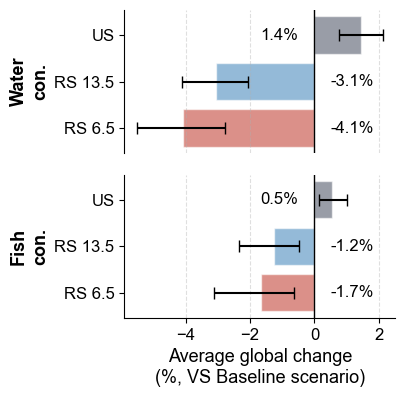

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 全局字体设为 Arial
mpl.rcParams["font.family"] = "Arial"

# =========================
# 1. 读取 summary_df
#    如果前面代码已经在内存里有 summary_df，就不用 read_csv
# =========================
summary_df = pd.read_csv(r"F:\User_file\wyy\SPDB\part3_forecast\relative_change_summary_quantiles.csv")

# =========================
# 2. 参数设置
# =========================
# 可选: "CI95" 或 "CI60"
ci_mode = "CI95"

# 中心值可选: "mean" 或 "median"
center_mode = "mean"

# ---------------------------
# 名称映射
# ---------------------------
type_order = ["sw", "lr"]
scene_order = ["high", "low", "us"]

scene_label_map = {
    "high": "RS 6.5",
    "low": "RS 13.5",
    "us": "US"
}

type_label_map = {
    "sw": "Water\ncon.",
    "lr": "Fish\ncon.",
}

color_map = {
    "high": "#c3473b",
    "low": "#4d8cbf",
    "us": "#555c6c"
}

# =========================
# 3. 根据 ci_mode 和 center_mode 生成绘图数据
# =========================
plot_df = summary_df.copy()

# 中心值
if center_mode == "mean":
    plot_df["center"] = plot_df["mean_percent"]
elif center_mode == "median":
    plot_df["center"] = plot_df["q50_percent"]
else:
    raise ValueError("center_mode 只能是 'mean' 或 'median'")

# 区间
if ci_mode == "CI95":
    plot_df["lower"] = plot_df["q2.5_percent"]
    plot_df["upper"] = plot_df["q97.5_percent"]
    x_label = "Average global change\n(%, VS Baseline scenario)"
elif ci_mode == "CI60":
    plot_df["lower"] = plot_df["q20_percent"]
    plot_df["upper"] = plot_df["q80_percent"]
    x_label = "Average global change \n(%, VS Baseline scenario)"
else:
    raise ValueError("ci_mode 只能是 'CI95' 或 'CI60'")

# 误差棒上下长度
plot_df["err_low"] = plot_df["center"] - plot_df["lower"]
plot_df["err_high"] = plot_df["upper"] - plot_df["center"]

# =========================
# 4. 绘图
# =========================
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(3.5, 4),
    sharex=True,
    gridspec_kw={"hspace": 0.15}
)

for i, (ax, t) in enumerate(zip(axes, type_order)):
    sub = plot_df[plot_df["type"] == t].copy()
    sub["scene"] = pd.Categorical(sub["scene"], categories=scene_order, ordered=True)
    sub = sub.sort_values("scene")

    y_pos = np.arange(len(sub))
    colors = [color_map[s] for s in sub["scene"]]

    ax.barh(
        y_pos,
        sub["center"].values,
        xerr=[sub["err_low"].values, sub["err_high"].values],
        color=colors,
        edgecolor="white",
        capsize=4,
        alpha=0.6,
        height=0.8
    )

    # 在 x=0 处画黑色实线
    ax.axvline(0, color="black", linestyle="-", linewidth=1)

    # scene 标签
    ax.set_yticks(y_pos)
    ax.set_yticklabels([scene_label_map[s] for s in sub["scene"]], fontsize=12)

    # type 作为 y 轴标题
    ax.set_ylabel(type_label_map[t], fontsize=13, fontweight="bold")

    # x/y 轴 tick 字体大小
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # 去除边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 前两个子图去掉下边框
    if i < 1:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    # ---------------------------
    # 数值标注
    # 正值标在 0 左边，负值标在 0 右边
    # ---------------------------
    for y, val in zip(y_pos, sub["center"].values):
        if val >= 0:
            ax.text(
                -0.5, y, f"{val:.1f}%",
                va="center", ha="right",
                fontsize=12, color="black"
            )
        else:
            ax.text(
                0.5, y, f"{val:.1f}%",
                va="center", ha="left",
                fontsize=12, color="black"
            )

axes[-1].set_xlabel(x_label, fontsize=13)

plt.tight_layout()
plt.savefig(
    rf"F:\User_file\wyy\SPDB\part3_forecast\relative_change_{ci_mode}_{center_mode}.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()